

# Importing necessary libraries


---




In [1]:
#Import Dependencies
%matplotlib inline

# Start Python Imports
import math, time, random, datetime

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
plt.style.use('seaborn-whitegrid')

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import model_selection, tree, preprocessing, metrics, linear_model
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
# Let's be rebels and ignore warnings for now
import warnings
warnings.filterwarnings('ignore')

# Reading the Dataset

---



In [2]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')

# A peek into the dataset we loaded

---



In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# To get a quick overview of train dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# To get a quick overview of test dataset
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# checking for null values in train dataset
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# checking for null values in test dataset
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<AxesSubplot:>

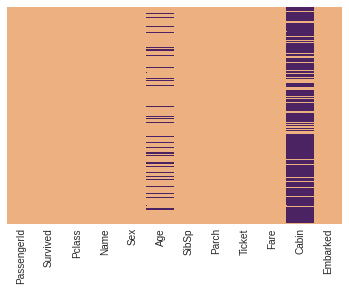

In [10]:
# heatmap plot to visualize the amount of missing values in train dataset
sns.heatmap(train.isnull(), cbar = False , 
            yticklabels = False , cmap = 'flare')

## We can see **Age** and **cabin** have a lot of missing values in the training set

<AxesSubplot:>

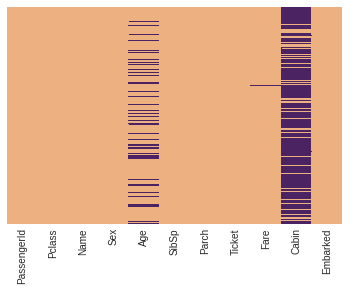

In [11]:
# heatmap plot to visualize the amount of missing values in test dataset
sns.heatmap(test.isnull(), cbar = False , 
            yticklabels = False , cmap = 'flare')

## We can see **Age** and **cabin** have a lot of missing values in the testing set.

---


In [12]:
# Function to create count and distribution visualization
def plot_count_dist(data, bin_df, label_column, target_column, figsize=(20, 5), use_bin_df=False):
    if use_bin_df: 
        fig = plt.figure(figsize=figsize)
        plt.subplot(1, 2, 1)
        sns.countplot(y=target_column, data=bin_df);
        plt.subplot(1, 2, 2)
        sns.distplot(data.loc[data[label_column] == 1][target_column], 
                     kde_kws={"label": "Survived"});
        sns.distplot(data.loc[data[label_column] == 0][target_column], 
                     kde_kws={"label": "Did not survive"});
    else:
        fig = plt.figure(figsize=figsize)
        plt.subplot(1, 2, 1)
        sns.countplot(y=target_column, data=data);
        plt.subplot(1, 2, 2)
        sns.distplot(data.loc[data[label_column] == 1][target_column], 
                     kde_kws={"label": "Survived"});
        sns.distplot(data.loc[data[label_column] == 0][target_column], 
                     kde_kws={"label": "Did not survive"});


# Data Preprocessing

0    549
1    342
Name: Survived, dtype: int64


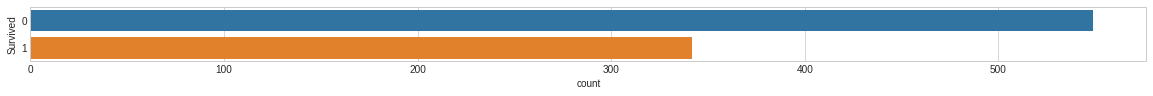

In [13]:
# Lets have a look at the number of people who survived
fig = plt.figure(figsize=(20,1))
sns.countplot(y='Survived', data=train);
print(train.Survived.value_counts())

# Analysing the feature **Age**

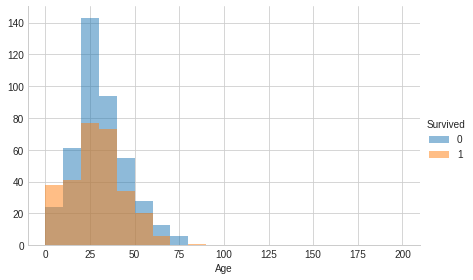

In [14]:
# visualize the distribution of Fare for people who survived and died
grid = sns.FacetGrid(train, hue='Survived', size=4, aspect=1.5)
grid.map(plt.hist, 'Age', alpha=.5, bins=range(0,210,10))
grid.add_legend()
plt.show()

## We can see that people with younger age are more likely to survive To prevent over-fitting by using the original values, we can use intervals of age to feed the ML algorithms.

In [15]:
#Replacing null values with the mean of the colummn
train['Age'].fillna((train['Age'].mean()), inplace=True)
test['Age'].fillna((test['Age'].mean()), inplace=True)

<AxesSubplot:>

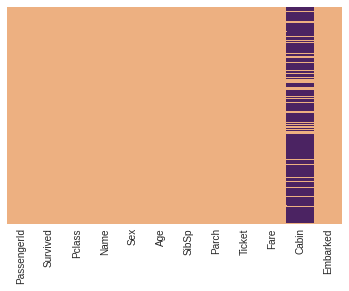

In [16]:
# age feature dealt with; no missing age records
sns.heatmap(train.isnull(), yticklabels = False, cbar = False, cmap = 'flare')

In [17]:
#binning the age feature
bins = [ 0, 4, 12, 18, 30, 50, 65, 100] # This is somewhat arbitrary
age_index = (1,2,3,4,5,6,7) #('baby','child','teenager','young','mid-age','over-50','senior')
train['Age'] = pd.cut(train.Age, bins, labels=age_index).astype(int)
test['Age'] = pd.cut(test.Age, bins, labels=age_index).astype(int)

In [18]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,4,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,4,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,5,0,0,373450,8.0500,NaN,S




---



# Analysing the feature **SibSp**

In [19]:
# checking for null values
train.SibSp.isnull().sum(axis=0), train.Parch.isnull().sum(axis=0)

(0, 0)

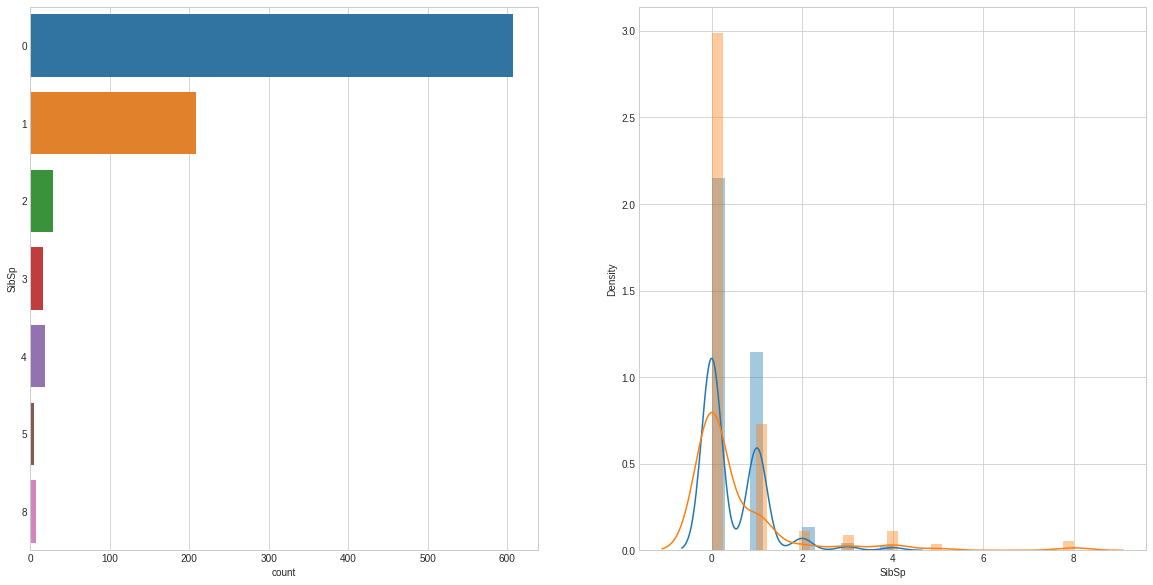

In [20]:
# Visualise the counts of SibSp and the distribution of the values against Survived
plot_count_dist(train,bin_df=train,label_column='Survived',target_column='SibSp',figsize=(20, 10))

# We can see that passengers having a lot of siblings/spouses have less chance to survive. 



# Analysing the feature **Sex**

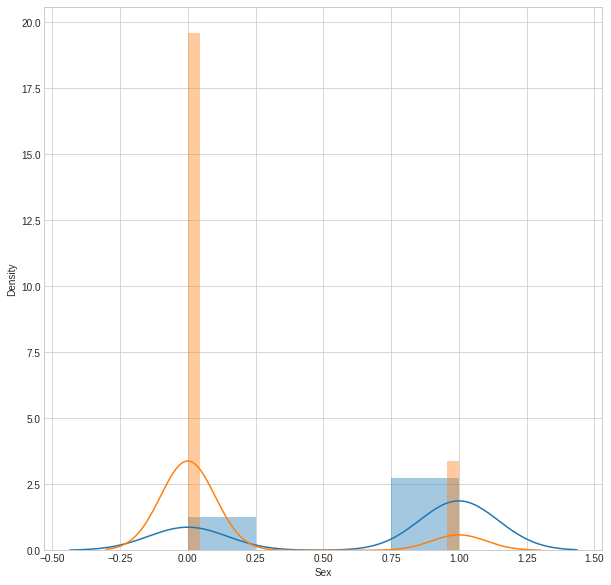

In [21]:
#which gender has a better chane at survival
train['Sex'] = np.where(train['Sex'] == 'female', 1, 0)
fig = plt.figure(figsize=(10, 10))
sns.distplot(train.loc[train['Survived'] == 1]['Sex'], kde_kws={'label': 'Survived'});
sns.distplot(train.loc[train['Survived'] == 0]['Sex'], kde_kws={'label': 'Did not survive'});


## More female passengers seem to have survived.


# Analysing the feature **Parch**

In [22]:
#missing values
train.Parch.isnull().sum()

0

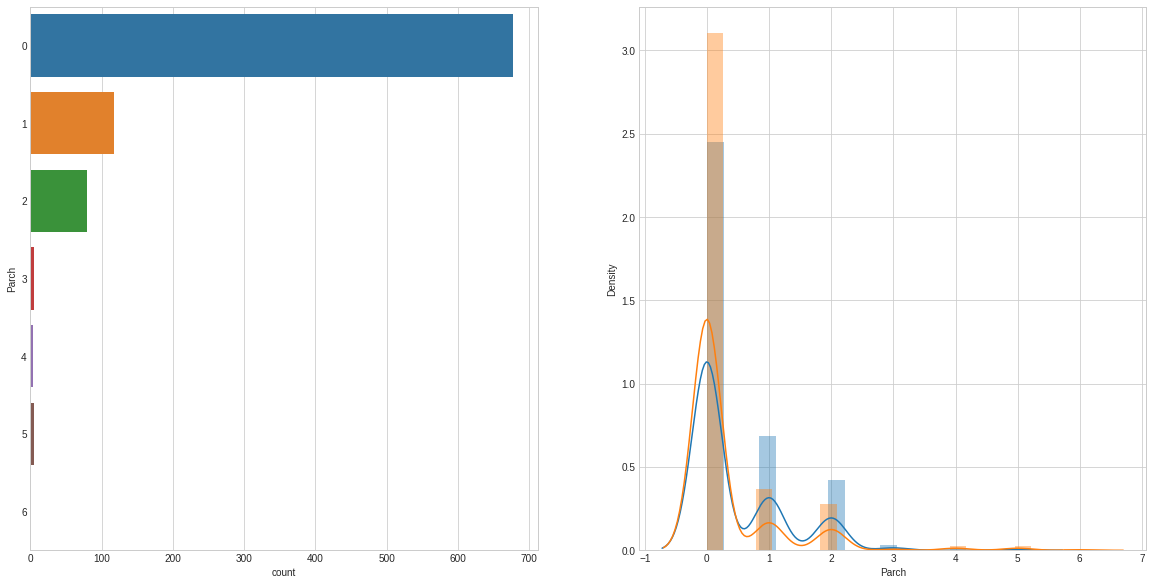

In [23]:
# Visualise the counts of Parch and the distribution of the values against Survived
plot_count_dist(train,bin_df=train,label_column='Survived',target_column='Parch',figsize=(20, 10))

## We can see that small families have more chance to survive, than single.

# Analysing the feature **Embarked**

In [24]:
# checking for null values
train.Embarked.isnull().sum()

2

<AxesSubplot:xlabel='count', ylabel='Embarked'>

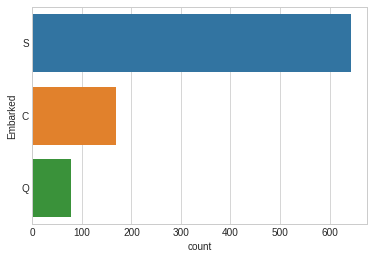

In [25]:
sns.countplot(y='Embarked', data=train)

In [26]:
# dropping the null values
train = train.dropna(subset=['Embarked'])
test = test.dropna(subset=['Embarked'])

# Analysing the feature **Fare**

In [27]:
#checking for null values
print(train.Fare.isnull().sum())
print(test.Fare.isnull().sum())

0
1


In [28]:
#replacing the null value in test dataset with the median
test['Fare'].fillna((test['Fare'].mean()), inplace=True)

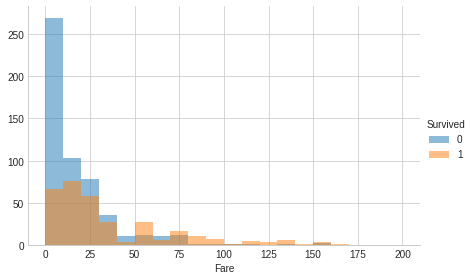

In [29]:
# visualizing the distribution of Fare for people who survived and died
grid = sns.FacetGrid(train, hue='Survived', size=4, aspect=1.5)
grid.map(plt.hist, 'Fare', alpha=.5, bins=range(0,210,10))
grid.add_legend()
plt.show()

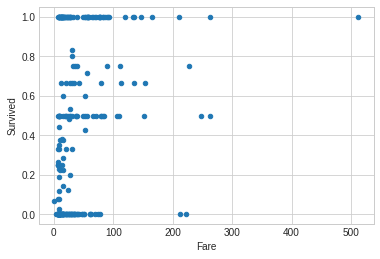

In [30]:
# visualizing the correlation between Fare and Survived using a scatter plot
train[['Fare', 'Survived']].groupby(['Fare'],as_index=False).mean().plot.scatter('Fare','Survived')
plt.show()


# We can see that people with lower Fare are less likely to survive. 

In [31]:
# bin Fare into five intervals with equal amount of people
train['Fare'] = pd.qcut(train.Fare,5,labels=[1,2,3,4,5]).astype(int)
test['Fare'] = pd.qcut(test.Fare,5,labels=[1,2,3,4,5]).astype(int)

# inspect the correlation between Fare-bin and Survived
train[['Fare', 'Survived']].groupby(['Fare'], as_index=False).mean()

,Fare,Survived
0,1,0.217877
1,2,0.201087
2,3,0.426901
3,4,0.441989
4,5,0.637931


## We can see that correlation much more clear after binning the data

# Analysing the feature **Cabin**

In [32]:
# check if there is any NAN
train.Cabin.isnull().sum(axis=0)

687

In [33]:
# There is too many NAN values so we drop this column
train = train.drop(labels=['Cabin'], axis=1)
test = test.drop(labels=['Cabin'],axis=1)

<AxesSubplot:>

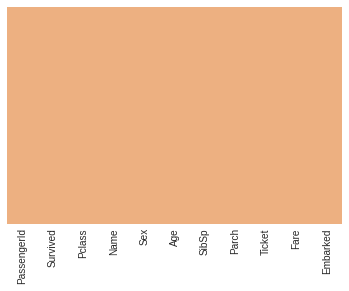

In [34]:
# heatmap plot to visualize the amount of missing values in train dataset
sns.heatmap(train.isnull(), cbar = False , 
            yticklabels = False , cmap = 'flare')

<AxesSubplot:>

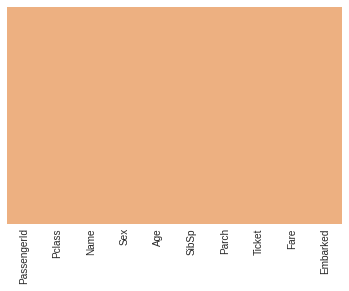

In [35]:
# heatmap plot to visualize the amount of missing values in test dataset
sns.heatmap(test.isnull(), cbar = False , 
            yticklabels = False , cmap = 'flare')

# Hence we can see all the null values are dealt with.

---


# Feature Encoding

In [36]:
# One hot encode the categorical columns
df_embarked_one_hot = pd.get_dummies(train['Embarked'], prefix='embarked')
df_sex_one_hot = pd.get_dummies(train['Sex'], prefix='sex')
df_plcass_one_hot = pd.get_dummies(train['Pclass'], prefix='pclass')
                                   
df_embarked_one_hot1 = pd.get_dummies(test['Embarked'], prefix='embarked')
df_sex_one_hot1 = pd.get_dummies(test['Sex'], prefix='sex')
df_plcass_one_hot1 = pd.get_dummies(test['Pclass'], prefix='pclass')
                                  

#combining the one hot encoded columns
train = pd.concat([train,df_embarked_one_hot, df_sex_one_hot,df_plcass_one_hot], axis=1)
test = pd.concat([test,df_embarked_one_hot1,df_sex_one_hot1,df_plcass_one_hot1], axis=1)


In [37]:
train=train.drop(['Pclass', 'Sex', 'Embarked'], axis=1)
test=test.drop(['Pclass', 'Sex', 'Embarked'], axis=1)

In [38]:
#dropping name and ticket
train=train.drop(['Name', 'Ticket'], axis=1)
test=test.drop(['Name', 'Ticket'], axis=1)

In [39]:
train.head()

,PassengerId,Survived,Age,SibSp,Parch,Fare,embarked_C,embarked_Q,embarked_S,sex_0,sex_1,pclass_1,pclass_2,pclass_3
0,1,0,4,1,0,1,0,0,1,1,0,0,0,1
1,2,1,5,1,0,5,1,0,0,0,1,1,0,0
2,3,1,4,0,0,2,0,0,1,0,1,0,0,1
3,4,1,5,1,0,5,0,0,1,0,1,1,0,0
4,5,0,5,0,0,2,0,0,1,1,0,0,0,1


# Modelling and Prediction

In [40]:
X_train = train.drop(["Survived",'PassengerId'], axis=1)
Y_train = train["Survived"]
X_test  = test.drop("PassengerId", axis=1).copy()

In [41]:
X_train.head()

,Age,SibSp,Parch,Fare,embarked_C,embarked_Q,embarked_S,sex_0,sex_1,pclass_1,pclass_2,pclass_3
0,4,1,0,1,0,0,1,1,0,0,0,1
1,5,1,0,5,1,0,0,0,1,1,0,0
2,4,0,0,2,0,0,1,0,1,0,0,1
3,5,1,0,5,0,0,1,0,1,1,0,0
4,5,0,0,2,0,0,1,1,0,0,0,1


In [42]:
X_test.head()

,Age,SibSp,Parch,Fare,embarked_C,embarked_Q,embarked_S,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,5,0,0,2,0,1,0,0,1,0,0,1
1,5,1,0,1,0,0,1,1,0,0,0,1
2,6,0,0,2,0,1,0,0,1,0,1,0
3,4,0,0,2,0,0,1,0,1,0,0,1
4,4,1,1,3,0,0,1,1,0,0,0,1


In [43]:
#Apply RandomForestClassifier
random_forest= RandomForestClassifier(n_estimators=100,
                             max_features='auto',
                             criterion='entropy',
                             max_depth=10)
random_forest.fit(X_train, Y_train)

Y_prediction = random_forest.predict(X_test)

random_forest.score(X_train, Y_train)
acc_random_forest = round(random_forest.score(X_train, Y_train) * 100, 2)
print(round(acc_random_forest,2,), "%")

89.54 %


In [44]:
#Apply GradientBoostingClassifier

from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
                                 max_depth=1, random_state=0).fit(X_train, Y_train)
y_prediction= clf.predict(X_test)
clf.score(X_train, Y_train)
acc_clf = round(clf.score(X_train, Y_train) * 100, 2)
print(round(acc_clf,2,), "%")

81.55 %


In [45]:
#Apply Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, Y_train)

Y_pred = logreg.predict(X_test)

acc_log = round(logreg.score(X_train, Y_train) * 100, 2)
print(round(acc_log,2,), "%")

79.53 %


In [46]:
# Apply Decision Tree
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, Y_train)

Y_pred = decision_tree.predict(X_test)

acc_decision_tree = round(decision_tree.score(X_train, Y_train) * 100, 2)
print(round(acc_decision_tree,2,), "%")

89.99 %


In [47]:
results = pd.DataFrame({
    'Model': [ 'Logistic Regression', 
              'Random Forest', 'Boosting', 
              'Decision Tree'],
    'Score': [ acc_log,
              acc_random_forest, acc_clf,
              acc_decision_tree]})
result_df = results.sort_values(by='Score', ascending=False)
result_df = result_df.set_index('Score')
result_df.head(7)

,Model
Score,
89.99,Decision Tree
89.54,Random Forest
81.55,Boosting
79.53,Logistic Regression


# So we can see that Decision Tree model performed best on our dataset


In [48]:
from sklearn.model_selection import cross_val_score
rf = RandomForestClassifier(n_estimators=100)
scores = cross_val_score(rf, X_train, Y_train, cv=10, scoring = "accuracy")
print("Scores:", scores)
print("Mean:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.78651685 0.83146067 0.73033708 0.84269663 0.8988764  0.79775281
 0.83146067 0.79775281 0.87640449 0.81818182]
Mean: 0.8211440245148109
Standard Deviation: 0.045079306416218226


In [49]:
y_preds = decision_tree.fit(X_train, Y_train).predict(X_test)
print("Score: ",decision_tree.score, 4*100, "%")


Score:  <bound method ClassifierMixin.score of DecisionTreeClassifier()> 400 %


In [50]:
submission = pd.DataFrame({
        "PassengerId": test['PassengerId'],
        "Survived":  y_preds
    })

submission.to_csv('submission.csv', index=False)